# WEEK 3 EDA for Google Apps Review
## Studi Kasus: Aplikasi Jenius (BTPN Digital Banking)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
import pandas as pd

# Tentukan path file dataset Jenius
file_path = '/content/drive/My Drive/PBA/rawdata_jenius_id.csv'

# Baca file CSV ke dalam DataFrame
df_jeniusrev = pd.read_csv(file_path, low_memory=False)

# Tampilkan beberapa baris pertama
df_jeniusrev.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c4fff659-dc8d-4449-92bd-c31e47cce376,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"payah udah cape"" isi data , login suruh isi da...",1,0,4.66.1,2026-03-23 09:31:49,Mohon maaf atas ketidaknyamanan yang kamu alam...,2026-03-23 09:32:47,4.66.1
1,cbfc7f4a-d5f6-48ef-a6f6-2a30ea8e159d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mohon bantu saya tidak pernah mengajukan pinja...,1,0,4.66.1,2026-03-23 07:25:07,Hi Sarwedi Silalahi. Mohon maaf atas ketidakny...,2026-03-23 07:32:36,4.66.1
2,163b3f92-772b-41d5-9c89-2d083ed3a355,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mobile banking paling berat dan lambat yang pe...,1,0,4.66.1,2026-03-22 23:24:37,Hi Kusnadi. Mohon maaf atas ketidaknyamanannya...,2026-03-22 23:31:12,4.66.1
3,b0eb2070-29d3-4f1d-b525-b2ecc70d0bda,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"tolong perbaiki sistemnya ya, kita sudah berus...",1,0,NaN,2026-03-22 13:33:56,Hai Andhy Hutomo. Terima kasih atas ulasan yan...,2026-03-22 13:35:34,NaN
4,e265485e-090f-4b1c-9a0b-6df7bdadebfd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya ingin unlink device, tapi sangat sulit. s...",1,0,4.66.1,2026-03-22 11:17:12,Hi Kak. Mohon maaf atas ketidaknyamanan yang d...,2026-03-22 11:19:39,4.66.1


# Exploratory Data Analysis (EDA) — Ulasan Aplikasi Jenius

## 1. Install Necessary Packages
Memastikan seluruh pustaka Python yang dibutuhkan telah terinstal sebelum menjalankan notebook.

In [8]:
!pip install pandas matplotlib seaborn nltk Sastrawi

## 2. Import Required Libraries
Mengimpor pustaka yang diperlukan untuk analisis data, visualisasi, dan pemrosesan teks.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string
import re

## 3. Download Stopwords
Mengunduh daftar stopwords bahasa Indonesia dari NLTK untuk kebutuhan pemrosesan teks.

In [25]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 4. Data Overview
Menampilkan informasi dasar dataset termasuk nama kolom, tipe data, dan beberapa baris pertama.

In [26]:
# Konversi kolom 'at' ke format datetime
df_jeniusrev['at'] = pd.to_datetime(df_jeniusrev['at'])

# Tampilkan info dataset
df_jeniusrev.info()
df_jeniusrev.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101151 entries, 0 to 101150
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              101151 non-null  object        
 1   userName              101151 non-null  object        
 2   userImage             101151 non-null  object        
 3   content               101147 non-null  object        
 4   score                 101151 non-null  int64         
 5   thumbsUpCount         101151 non-null  int64         
 6   reviewCreatedVersion  69106 non-null   object        
 7   at                    101151 non-null  datetime64[ns]
 8   replyContent          29697 non-null   object        
 9   repliedAt             29697 non-null   object        
 10  appVersion            69106 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 8.5+ MB


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c4fff659-dc8d-4449-92bd-c31e47cce376,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"payah udah cape"" isi data , login suruh isi da...",1,0,4.66.1,2026-03-23 09:31:49,Mohon maaf atas ketidaknyamanan yang kamu alam...,2026-03-23 09:32:47,4.66.1
1,cbfc7f4a-d5f6-48ef-a6f6-2a30ea8e159d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mohon bantu saya tidak pernah mengajukan pinja...,1,0,4.66.1,2026-03-23 07:25:07,Hi Sarwedi Silalahi. Mohon maaf atas ketidakny...,2026-03-23 07:32:36,4.66.1
2,163b3f92-772b-41d5-9c89-2d083ed3a355,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mobile banking paling berat dan lambat yang pe...,1,0,4.66.1,2026-03-22 23:24:37,Hi Kusnadi. Mohon maaf atas ketidaknyamanannya...,2026-03-22 23:31:12,4.66.1
3,b0eb2070-29d3-4f1d-b525-b2ecc70d0bda,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"tolong perbaiki sistemnya ya, kita sudah berus...",1,0,NaN,2026-03-22 13:33:56,Hai Andhy Hutomo. Terima kasih atas ulasan yan...,2026-03-22 13:35:34,NaN
4,e265485e-090f-4b1c-9a0b-6df7bdadebfd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya ingin unlink device, tapi sangat sulit. s...",1,0,4.66.1,2026-03-22 11:17:12,Hi Kak. Mohon maaf atas ketidaknyamanan yang d...,2026-03-22 11:19:39,4.66.1


## 5. Missing Values Analysis
Mengidentifikasi dan menghitung jumlah nilai kosong pada setiap kolom.

In [27]:
missing_values = df_jeniusrev.isnull().sum()
print('Missing Values Summary:')
print(missing_values)

Missing Values Summary:
reviewId                    0
userName                    0
userImage                   0
content                     4
score                       0
thumbsUpCount               0
reviewCreatedVersion    32045
at                          0
replyContent            71454
repliedAt               71454
appVersion              32045
dtype: int64


## 6. Review Score Distribution
Memvisualisasikan distribusi skor ulasan untuk memahami sentimen pengguna secara keseluruhan.

/tmp/ipykernel_18365/1351715134.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_jeniusrev['score'], palette='viridis')


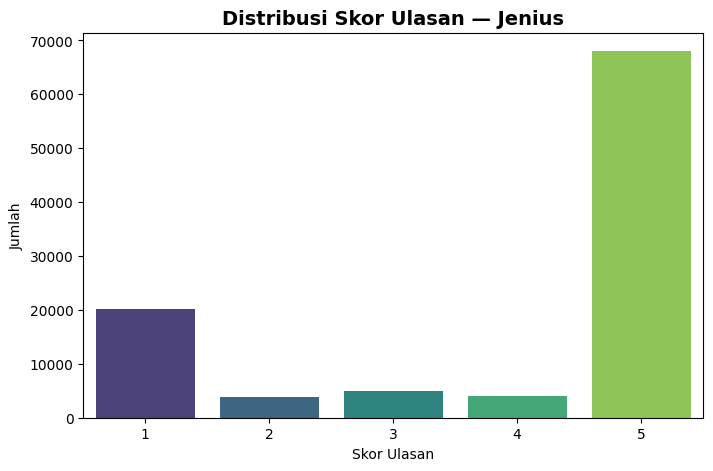

In [30]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df_jeniusrev['score'], palette='viridis')
plt.title('Distribusi Skor Ulasan — Jenius', fontsize=14, fontweight='bold')
plt.xlabel('Skor Ulasan')
plt.ylabel('Jumlah')
plt.show()

## 7. Review Trends Over Time
Menganalisis bagaimana jumlah ulasan berubah dari waktu ke waktu untuk mendeteksi pola tertentu.

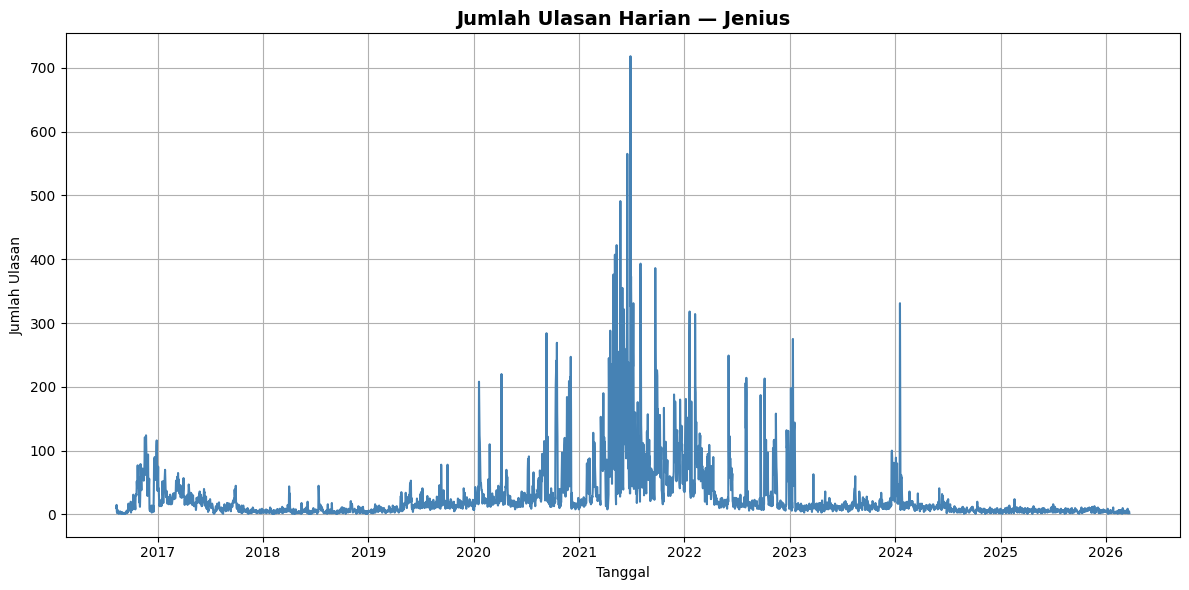

In [33]:
# Ekstrak tanggal ulasan
df_jeniusrev['review_date'] = df_jeniusrev['at'].dt.date
review_trend = df_jeniusrev.groupby('review_date').size()

plt.figure(figsize=(12, 6))
review_trend.plot(color='steelblue')
plt.title('Jumlah Ulasan Harian — Jenius', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Ulasan')
plt.grid(True)
plt.tight_layout()
plt.show()

## 8. Word Frequency Analysis
Menganalisis kata-kata yang paling sering muncul dalam ulasan, dengan mengecualikan stopwords bahasa Indonesia.

In [34]:
# Muat stopwords bahasa Indonesia
stop_words = set(stopwords.words('indonesian'))

# Gabungkan seluruh teks ulasan
all_reviews = ' '.join(df_jeniusrev['content'].dropna()).lower()
all_reviews = all_reviews.translate(str.maketrans('', '', string.punctuation))

# Tokenisasi dan filter stopwords
words = all_reviews.split()
filtered_words = [word for word in words if word not in stop_words]

# Hitung frekuensi kata
word_counts = Counter(filtered_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

print('Most Common Words in Reviews:')
print(common_words)

Most Common Words in Reviews:
           Word  Frequency
0      aplikasi      46373
1        jenius      34900
2         mudah      19086
3        banget      15703
4           nya      14972
5         bagus      14145
6          bank      10039
7            yg       9933
8      membantu       9859
9           top       9211
10          gak       8860
11           ga       8434
12           up       8348
13     menabung       8212
14       online       7578
15    transaksi       6931
16  aplikasinya       6335
17     aktivasi       6185
18        cepat       5859
19          aja       5666


## 9. Word Frequency Visualization
Memvisualisasikan kata-kata yang paling sering muncul dalam bentuk diagram batang horizontal.

/tmp/ipykernel_18365/3110247916.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=common_words, palette='Blues_r')


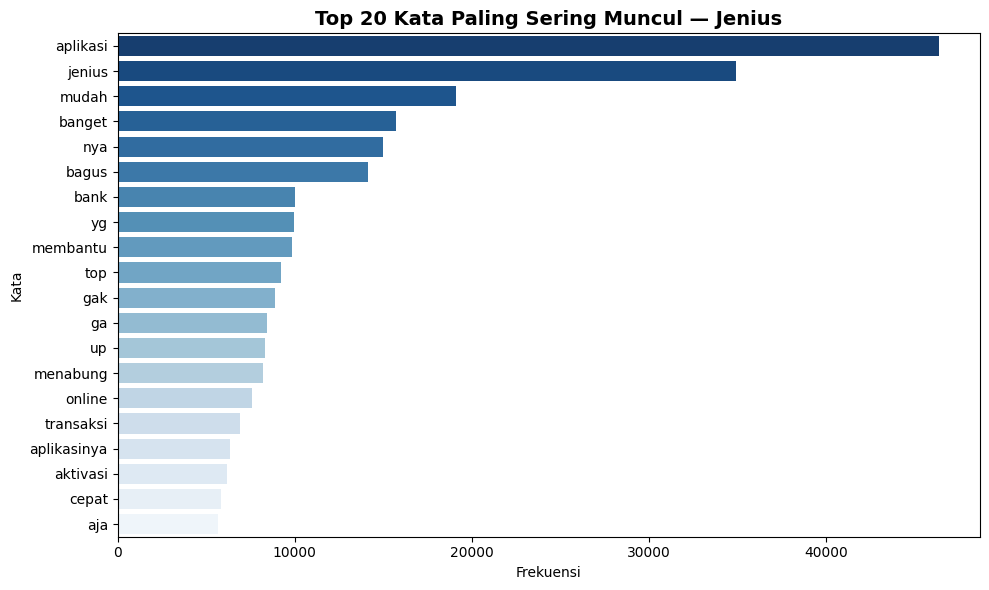

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y='Word', data=common_words, palette='Blues_r')
plt.title('Top 20 Kata Paling Sering Muncul — Jenius', fontsize=14, fontweight='bold')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.tight_layout()
plt.show()

## 10. Sentiment Distribution (Positive, Neutral, Negative)
Melabeli setiap ulasan berdasarkan skor rating menjadi tiga kategori sentimen: Positif, Netral, dan Negatif.

/tmp/ipykernel_18365/4134343633.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


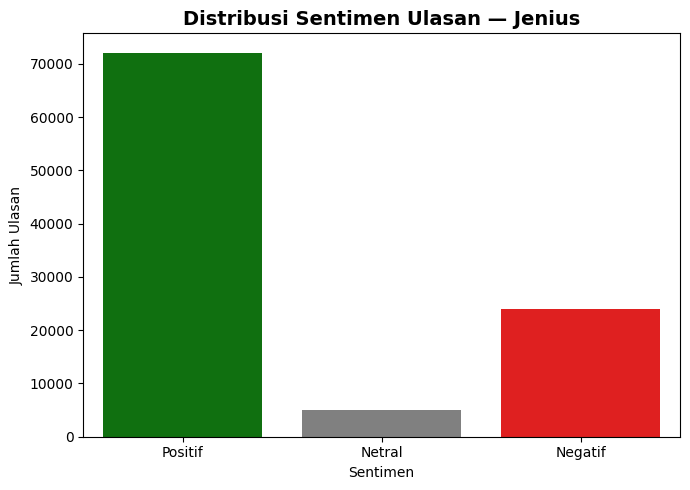


Jumlah per Sentimen:
sentiment
Positif    72123
Negatif    24057
Netral      4971
Name: count, dtype: int64


In [36]:
# Labeling sentimen berdasarkan skor rating
df_jeniusrev['sentiment'] = df_jeniusrev['score'].apply(
    lambda x: 'Positif' if x >= 4 else ('Netral' if x == 3 else 'Negatif')
)

plt.figure(figsize=(7, 5))
sns.countplot(
    x='sentiment', data=df_jeniusrev,
    palette={'Positif': 'green', 'Netral': 'gray', 'Negatif': 'red'},
    order=['Positif', 'Netral', 'Negatif']
)
plt.title('Distribusi Sentimen Ulasan — Jenius', fontsize=14, fontweight='bold')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.tight_layout()
plt.show()

print('\nJumlah per Sentimen:')
print(df_jeniusrev['sentiment'].value_counts())

## 11. Word Frequency by Sentiment
Menganalisis kata-kata yang paling sering muncul secara terpisah pada ulasan Positif dan Negatif
untuk mengekstraksi insight dari masing-masing kelompok sentimen.

/tmp/ipykernel_18365/2576483328.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df_top_pos, palette='Greens_r', ax=axes[0])
/tmp/ipykernel_18365/2576483328.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df_top_neg, palette='Reds_r', ax=axes[1])


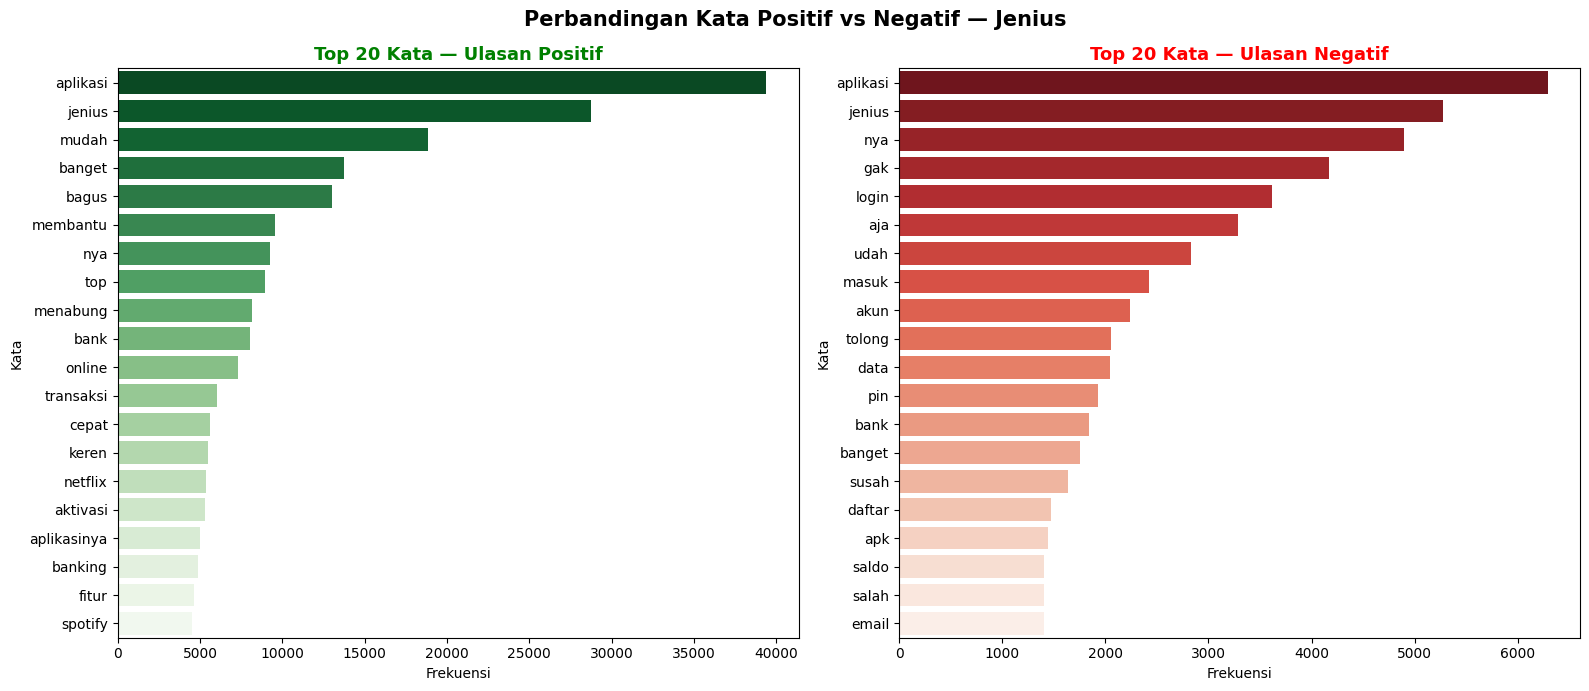


Most Common Words — Ulasan Positif:
           Word  Frequency
0      aplikasi      39383
1        jenius      28772
2         mudah      18858
3        banget      13743
4         bagus      13013
5      membantu       9583
6           nya       9231
7           top       8935
8      menabung       8147
9          bank       8007
10       online       7312
11    transaksi       6043
12        cepat       5605
13        keren       5476
14      netflix       5363
15     aktivasi       5284
16  aplikasinya       5020
17      banking       4891
18        fitur       4628
19      spotify       4526

Most Common Words — Ulasan Negatif:
        Word  Frequency
0   aplikasi       6289
1     jenius       5278
2        nya       4895
3        gak       4168
4      login       3613
5        aja       3284
6       udah       2831
7      masuk       2424
8       akun       2240
9     tolong       2057
10      data       2048
11       pin       1931
12      bank       1841
13    banget       1752

In [37]:
def get_top_words(df, sentiment_label, n=20):
    """Mengambil n kata terbanyak dari kelompok sentimen tertentu."""
    reviews = ' '.join(df[df['sentiment'] == sentiment_label]['content'].dropna()).lower()
    reviews = reviews.translate(str.maketrans('', '', string.punctuation))
    words = [w for w in reviews.split() if w not in stop_words and len(w) > 2]
    return Counter(words).most_common(n)

# Ambil top kata positif dan negatif
top_positif = get_top_words(df_jeniusrev, 'Positif')
top_negatif = get_top_words(df_jeniusrev, 'Negatif')

df_top_pos = pd.DataFrame(top_positif, columns=['Word', 'Frequency'])
df_top_neg = pd.DataFrame(top_negatif, columns=['Word', 'Frequency'])

# Visualisasi berdampingan
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(x='Frequency', y='Word', data=df_top_pos, palette='Greens_r', ax=axes[0])
axes[0].set_title('Top 20 Kata — Ulasan Positif', fontsize=13, fontweight='bold', color='green')
axes[0].set_xlabel('Frekuensi')
axes[0].set_ylabel('Kata')

sns.barplot(x='Frequency', y='Word', data=df_top_neg, palette='Reds_r', ax=axes[1])
axes[1].set_title('Top 20 Kata — Ulasan Negatif', fontsize=13, fontweight='bold', color='red')
axes[1].set_xlabel('Frekuensi')
axes[1].set_ylabel('Kata')

plt.suptitle('Perbandingan Kata Positif vs Negatif — Jenius', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nMost Common Words — Ulasan Positif:')
print(df_top_pos)
print('\nMost Common Words — Ulasan Negatif:')
print(df_top_neg)

## 12. Monthly Review Trend
Menganalisis tren jumlah ulasan per bulan untuk melihat fluktuasi aktivitas pengguna
dalam memberikan umpan balik terhadap aplikasi Jenius.

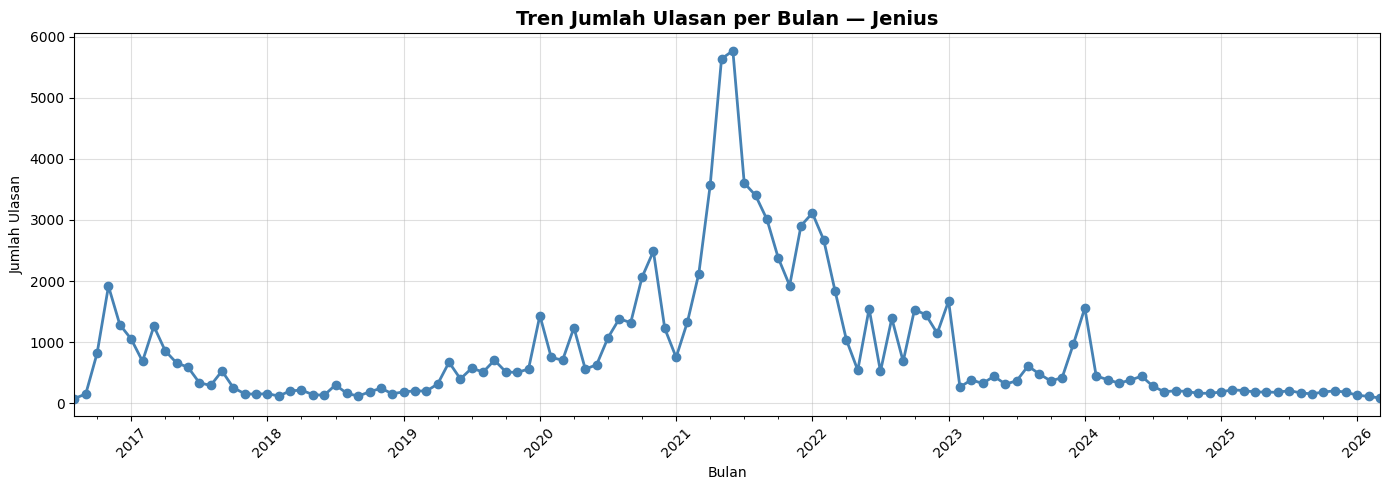

In [38]:
# Tambahkan kolom bulan-tahun
df_jeniusrev['year_month'] = df_jeniusrev['at'].dt.to_period('M')
monthly_trend = df_jeniusrev.groupby('year_month').size()

plt.figure(figsize=(14, 5))
monthly_trend.plot(marker='o', color='steelblue', linewidth=2)
plt.title('Tren Jumlah Ulasan per Bulan — Jenius', fontsize=14, fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Ulasan')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 13. Average Score per Year
Menghitung rata-rata skor ulasan per tahun untuk mengevaluasi tren kepuasan pengguna
terhadap aplikasi Jenius secara kronologis.

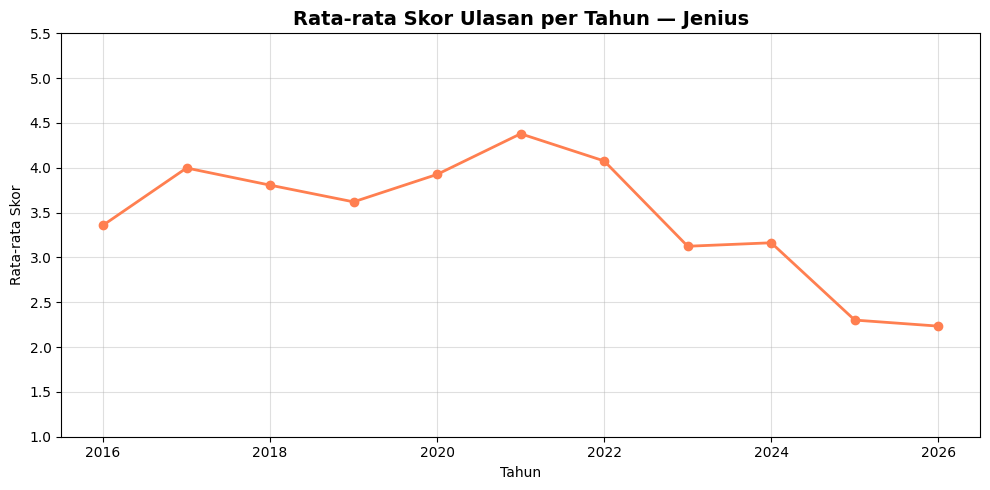

In [39]:
# Tambahkan kolom tahun
df_jeniusrev['year'] = df_jeniusrev['at'].dt.year
avg_score_year = df_jeniusrev.groupby('year')['score'].mean()

plt.figure(figsize=(10, 5))
avg_score_year.plot(marker='o', color='coral', linewidth=2)
plt.title('Rata-rata Skor Ulasan per Tahun — Jenius', fontsize=14, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Skor')
plt.ylim(1, 5.5)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 14. Review Length Analysis
Menganalisis panjang teks ulasan (jumlah karakter) untuk memahami seberapa deskriptif
pengguna dalam menyampaikan umpan balik pada setiap kategori skor.

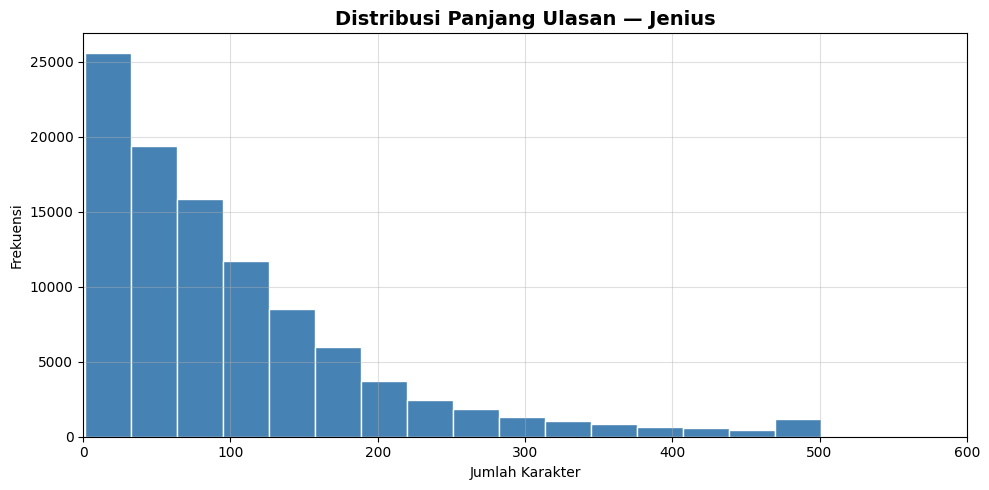


Statistik Panjang Ulasan per Skor:
       count        mean  median   max
score                                 
1      20194  118.498663    89.0  1564
2       3863  109.320994    84.0   937
3       4971   86.271977    61.0   625
4       4092   66.423265    39.0   591
5      68031   98.273125    71.0   770


In [41]:
# Hitung panjang setiap ulasan
df_jeniusrev['review_length'] = df_jeniusrev['content'].astype(str).apply(len)

plt.figure(figsize=(10, 5))
plt.hist(df_jeniusrev['review_length'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribusi Panjang Ulasan — Jenius', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.xlim(0, 600)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# Statistik deskriptif panjang ulasan per skor
print('\nStatistik Panjang Ulasan per Skor:')
print(df_jeniusrev.groupby('score')['review_length'].agg(['count', 'mean', 'median', 'max']))

## 15. Developer Reply Rate
Mengukur tingkat responsivitas pengembang terhadap ulasan pengguna dengan menghitung
persentase ulasan yang mendapatkan balasan dari pihak Jenius.

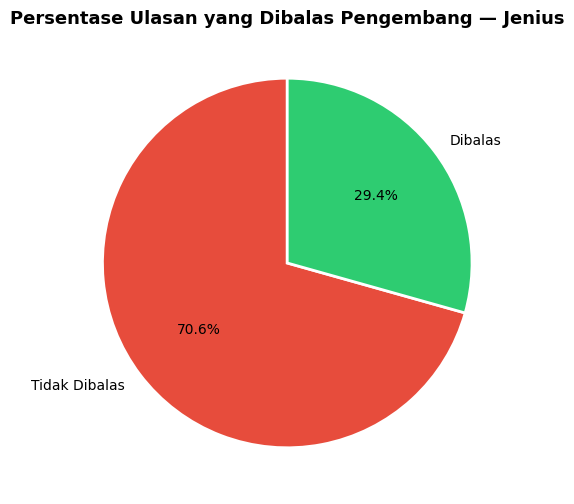

Dibalas       : 29,697 (29.4%)
Tidak Dibalas : 71,454 (70.6%)


In [43]:
import matplotlib.pyplot as plt

# 1. Tandai ulasan yang mendapat balasan
df_jeniusrev['is_replied'] = df_jeniusrev['replyContent'].notnull()
reply_counts = df_jeniusrev['is_replied'].value_counts()

# 2. Buat mapping label agar tidak error jika salah satu kategori kosong
label_map = {True: 'Dibalas', False: 'Tidak Dibalas'}
current_labels = [label_map[idx] for idx in reply_counts.index]

# 3. Warna yang menyesuaikan index (Merah untuk False, Hijau untuk True)
color_map = {False: '#e74c3c', True: '#2ecc71'}
current_colors = [color_map[idx] for idx in reply_counts.index]

plt.figure(figsize=(6, 6))
plt.pie(
    reply_counts,
    labels=current_labels, # Label otomatis sesuai data yang ada
    autopct='%1.1f%%',
    colors=current_colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    startangle=90 # Biar posisi pie chart-nya lebih rapi
)

plt.title('Persentase Ulasan yang Dibalas Pengembang — Jenius',
          fontsize=13, fontweight='bold')
plt.show()

# 4. Print statistik dengan handling error jika salah satu index tidak ada
total = reply_counts.sum()
cnt_true = reply_counts.get(True, 0)
cnt_false = reply_counts.get(False, 0)

print(f'Dibalas       : {cnt_true:,} ({cnt_true/total*100:.1f}%)')
print(f'Tidak Dibalas : {cnt_false:,} ({cnt_false/total*100:.1f}%)')

## 16. Summary Statistics
Menampilkan ringkasan statistik deskriptif dari seluruh dataset ulasan Jenius
sebagai validasi akhir sebelum tahap analisis lebih lanjut.

In [44]:
# Ringkasan statistik deskriptif
print('=== RINGKASAN DATASET ULASAN JENIUS ===')
print(f'Total ulasan       : {len(df_jeniusrev):,}')
print(f'Rentang waktu      : {df_jeniusrev["at"].min().date()} s/d {df_jeniusrev["at"].max().date()}')
print(f'Rata-rata skor     : {df_jeniusrev["score"].mean():.2f}')
print(f'Median skor        : {df_jeniusrev["score"].median()}')
print(f'Ulasan dibalas     : {df_jeniusrev["is_replied"].sum():,}')
print()
df_jeniusrev.describe()

=== RINGKASAN DATASET ULASAN JENIUS ===
Total ulasan       : 101,151
Rentang waktu      : 2016-08-11 s/d 2026-03-23
Rata-rata skor     : 3.95
Median skor        : 5.0
Ulasan dibalas     : 29,697



,score,thumbsUpCount,at,year,review_length
count,101151.000000,101151.000000,101151,101151.000000,101151.000000
mean,3.948117,1.222183,2021-04-03 09:29:37.346423040,2020.753675,100.854663
min,1.000000,0.000000,2016-08-11 05:06:14,2016.000000,1.000000
25%,3.000000,0.000000,2020-08-13 12:31:03.500000,2020.000000,32.000000
50%,5.000000,0.000000,2021-06-21 00:36:23,2021.000000,73.000000
75%,5.000000,0.000000,2022-03-04 09:42:40.500000,2022.000000,137.000000
max,5.000000,1250.000000,2026-03-23 09:31:49,2026.000000,1564.000000
std,1.633581,10.413876,NaN,1.975932,97.777140
